# 03 Q3 Design Justification

Paper-ready single-subfigure exports for Q3.

In [1]:
import importlib
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

import real_final_viz_helpers as viz
importlib.reload(viz)

PALETTE = viz.PALETTE
apply_style = viz.apply_style
bar_line_panel = viz.bar_line_panel
load_csv = viz.load_csv
mark_ours_first = viz.mark_ours_first
half_legend_strip_axes = viz.half_legend_strip_axes
single_subfigure_axes = viz.single_subfigure_axes
add_legend_strip = viz.add_legend_strip

ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = Path('/workspace/FeaturedMoE/writing/260419_real_final_exp')
FIG_DIR = Path('/workspace/FeaturedMoE/writing/ACM_template/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)
apply_style()

In [2]:
q3_temporal = load_csv('q3_temporal_decomp.csv')
q3_org = load_csv('q3_routing_org.csv')

def select_best_hparam_then_average(df):
    scored = (
        df.groupby(['dataset', 'variant_label', 'variant_order', 'base_rank'], as_index=False)
        [['best_valid_seen_mrr20', 'test_ndcg20', 'test_hit10']]
        .mean()
    )
    best = (
        scored.sort_values(
            ['dataset', 'variant_order', 'best_valid_seen_mrr20', 'test_ndcg20', 'test_hit10', 'base_rank'],
            ascending=[True, True, False, False, False, True],
            kind='stable',
        )
        .drop_duplicates(['dataset', 'variant_label', 'variant_order'], keep='first')
        .sort_values(['dataset', 'variant_order'], kind='stable')
        .reset_index(drop=True)
    )
    return best

temporal_plot = select_best_hparam_then_average(q3_temporal)
temporal_plot = temporal_plot[temporal_plot['dataset'] == 'KuaiRecLargeStrictPosV2_0.2'].copy()
org_plot = select_best_hparam_then_average(q3_org)
org_plot = org_plot[org_plot['dataset'] == 'KuaiRecLargeStrictPosV2_0.2'].copy()

temporal_short = {
    'Final 3-stage': '3-scope',
    'Best 2-view': '2-scope',
    'Single-view': '1-scope',
}
org_short = {
    'Hierarchical sparse': 'Hierarchical sparse',
    'Hierarchical dense': 'Hierarchical dense',
    'Flat dense': 'Flat dense',
    'Flat sparse': 'Flat sparse',
}
temporal_plot['variant_display'] = temporal_plot['variant_label'].map(temporal_short).fillna(temporal_plot['variant_label'])
org_plot['variant_display'] = org_plot['variant_label'].map(org_short).fillna(org_plot['variant_label'])

temporal_order = ['3-scope', '2-scope', '1-scope']
org_order = ['Hierarchical sparse', 'Flat dense', 'Flat sparse', 'Hierarchical dense']
temporal_legend = mark_ours_first(temporal_order)
org_legend = mark_ours_first(org_order)
temporal_palette = {
    '3-scope': PALETTE['route'],
    '2-scope': PALETTE['orange'],
    '1-scope': PALETTE['blue'],
}
org_palette = {
    'Hierarchical sparse': PALETTE['route'],
    'Flat dense': PALETTE['blue'],
    'Flat sparse': PALETTE['orange'],
    'Hierarchical dense': PALETTE['plum'],
}
temporal_colors = [temporal_palette[label] for label in temporal_order]
org_colors = [org_palette[label] for label in org_order]
print('prepared Q3 rows', len(temporal_plot), len(org_plot))

prepared Q3 rows 3 4


[saved] /workspace/FeaturedMoE/writing/ACM_template/figures/fig_q3_design_justification_a.pdf


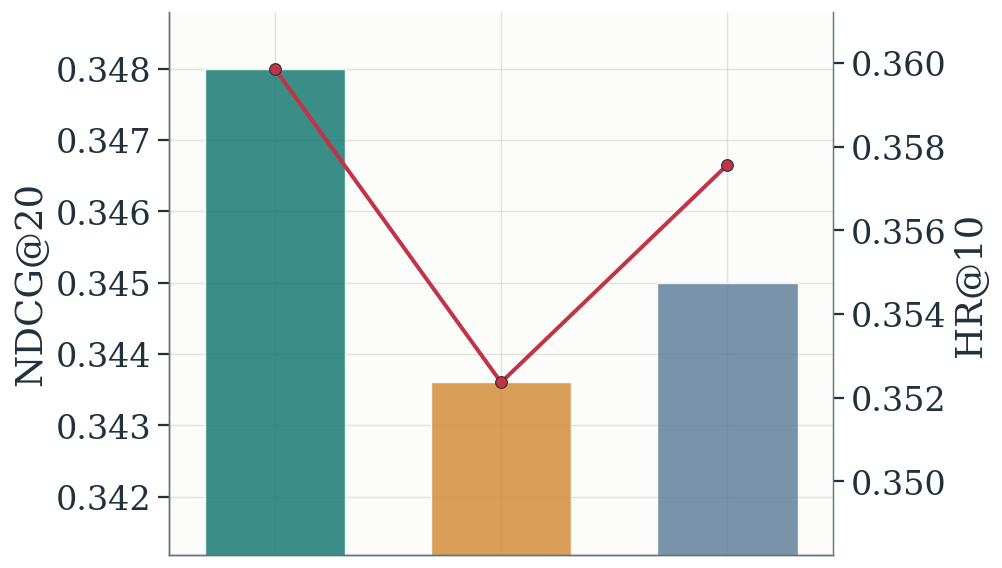

In [3]:
fig, ax = single_subfigure_axes()
bar_line_panel(
    temporal_plot,
    category_col='variant_display',
    ndcg_col='test_ndcg20',
    hr_col='test_hit10',
    ax=ax,
    order=temporal_order,
    xrotation=0,
    palette_override=temporal_palette,
    show_xticklabels=False,
    add_metric_legend_box=False,
)
fig.savefig(FIG_DIR / 'fig_q3_design_justification_a.pdf', bbox_inches='tight')
print('[saved]', FIG_DIR / 'fig_q3_design_justification_a.pdf')
plt.show()

[saved] /workspace/FeaturedMoE/writing/ACM_template/figures/fig_q3_design_justification_b.pdf


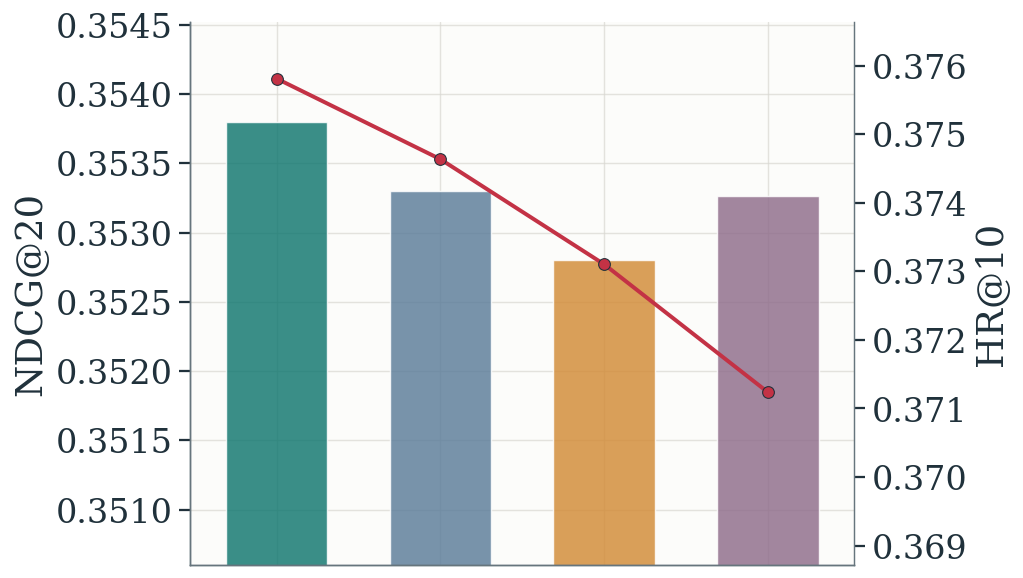

In [4]:
fig, ax = single_subfigure_axes()
bar_line_panel(
    org_plot,
    category_col='variant_display',
    ndcg_col='test_ndcg20',
    hr_col='test_hit10',
    ax=ax,
    order=org_order,
    xrotation=0,
    palette_override=org_palette,
    show_xticklabels=False,
    add_metric_legend_box=False,
)
fig.savefig(FIG_DIR / 'fig_q3_design_justification_b.pdf', bbox_inches='tight')
print('[saved]', FIG_DIR / 'fig_q3_design_justification_b.pdf')
plt.show()

[saved] /workspace/FeaturedMoE/writing/ACM_template/figures/fig_q3_design_justification_a_legend.pdf


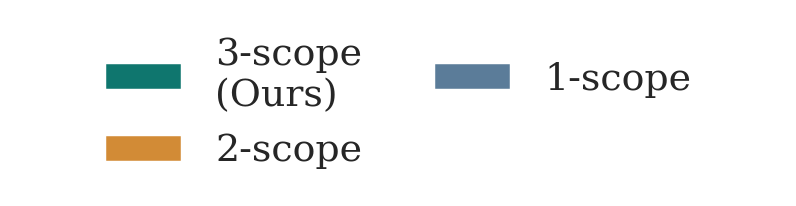

In [5]:
fig, ax = half_legend_strip_axes()
add_legend_strip(ax, temporal_legend, temporal_colors, ncol=2)
fig.savefig(FIG_DIR / 'fig_q3_design_justification_a_legend.pdf', bbox_inches='tight')
print('[saved]', FIG_DIR / 'fig_q3_design_justification_a_legend.pdf')
plt.show()

[saved] /workspace/FeaturedMoE/writing/ACM_template/figures/fig_q3_design_justification_b_legend.pdf


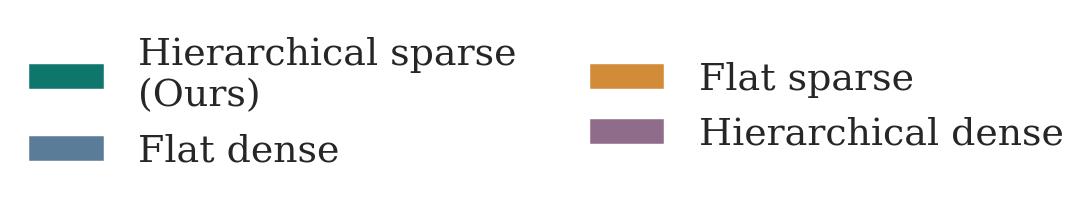

In [6]:
fig, ax = half_legend_strip_axes()
add_legend_strip(ax, org_legend, org_colors, ncol=2)
fig.savefig(FIG_DIR / 'fig_q3_design_justification_b_legend.pdf', bbox_inches='tight')
print('[saved]', FIG_DIR / 'fig_q3_design_justification_b_legend.pdf')
plt.show()